## Importing Libraries

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### Importing Datasets

In [2]:
data = pd.read_csv("laptop_prices.csv")

### Data Understanding

In [3]:
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

Number of rows: 1275
Number of columns: 23


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [5]:
data.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [6]:
print("Checking For any null values:")
data.isnull().sum()

Checking For any null values:


Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [7]:
print(f"Duplicated Values: {data.duplicated().sum()}")

Duplicated Values: 0


In [8]:
data.sample(10)

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
261,Lenovo,IdeaPad 320-15ISK,Notebook,15.6,4,No OS,2.20,444.00,Full HD,1920,...,No,Intel,2.0,Core i3 6006U,256,0,SSD,No,Intel,HD Graphics 520
1215,Acer,C740-C9QX (3205U/2GB/32GB/Chrome,Netbook,11.6,2,Chrome OS,1.30,174.00,Standard,1366,...,No,Intel,1.5,Celeron Dual Core 3205U,32,0,SSD,No,Intel,HD Graphics
102,Dell,Inspiron 3576,Notebook,15.6,8,Linux,2.20,647.00,Full HD,1920,...,No,Intel,1.6,Core i5 8250U,1024,0,HDD,No,AMD,Radeon 520
264,Dell,Inspiron 3567,Notebook,15.6,8,Windows 10,2.24,565.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,1024,0,HDD,No,AMD,Radeon R5 M430
939,Dell,Alienware 17,Gaming,17.3,16,Windows 10,4.36,2758.00,Standard,2560,...,No,Intel,2.7,Core i7 6820HK,512,1024,SSD,HDD,Nvidia,GeForce GTX 1080
52,HP,255 G6,Notebook,15.6,4,Windows 10,1.86,398.49,Full HD,1920,...,No,AMD,2.5,A6-Series 9220,256,0,SSD,No,AMD,Radeon R4 Graphics
494,Asus,Rog G752VL-UH71T,Gaming,17.3,24,Windows 10,4.33,1269.00,Full HD,1920,...,No,Intel,2.6,Core i7 6700HQ,256,1024,SSD,HDD,Nvidia,GeForce GTX 965M
195,HP,ProBook 470,Notebook,17.3,8,Windows 10,2.50,914.00,Full HD,1920,...,No,Intel,1.6,Core i5 8250U,1024,0,HDD,No,Nvidia,GeForce 930MX
1193,Apple,"MacBook 12""",Ultrabook,12.0,8,Mac OS X,0.92,1163.00,Standard,2304,...,Yes,Intel,1.1,Core M,256,0,Flash Storage,No,Intel,HD Graphics 5300
1211,Asus,FX502VM-AS73 (i7-7700HQ/16GB/1TB,Notebook,15.6,16,Windows 10,2.20,1749.00,Full HD,1920,...,No,Intel,2.8,Core i7 7700HQ,128,1024,SSD,HDD,Nvidia,GeForce GTX 1060


## Exploratory Data Analysis [EDA]
----------------------------------
### 1. Target Columns Analysis [Price]

In [9]:
print(f"Maximum Spent: €{data['Price_euros'].max()}")
print(f"\nMinimum Spent: €{data['Price_euros'].min()}")
print(f"\nAverage Spending: €{data['Price_euros'].median()}")
print(f"\nMean: {data['Price_euros'].mean()}")
print(f"Median: {data['Price_euros'].median()}")
print(f"Standard Deviation: {data['Price_euros'].std()}")

Maximum Spent: €6099.0

Minimum Spent: €174.0

Average Spending: €989.0

Mean: 1134.9690588235292
Median: 989.0
Standard Deviation: 700.7525041749287


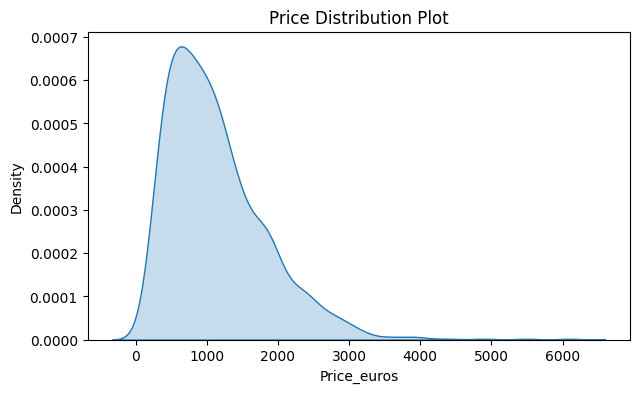

In [10]:
# Checking for Distribution:

plt.figure(figsize=(7,4))
sns.kdeplot(data=data, x=data['Price_euros'], fill=True)
plt.title("Price Distribution Plot")
plt.show()

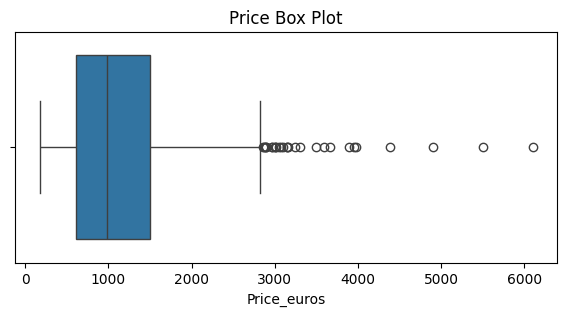

In [11]:
# Checking for outliers:

plt.figure(figsize=(7,3))
sns.boxplot(data=data, x=data['Price_euros'], fill=True)
plt.title("Price Box Plot")
plt.show()

The minimum spent by a person is €174 and maximum spent is €6099, showing a large price range in the dataset.

The mean price (€1134) which is higher than the median (€989), indicating that distribution is right-skewed (as we can see in the kde-plot).

The box-plot shows several outliers, suggesting premium laptops influences price distribution.

## 2. Categorial Columns Analysis

Total Companies: 19



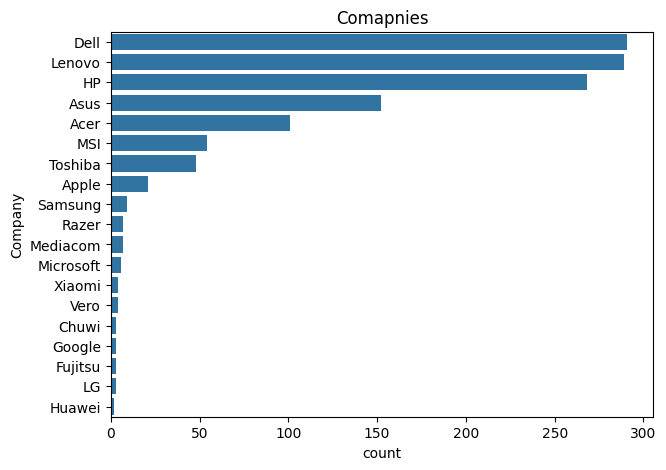

In [12]:
# Company Analysis: 

print(f"Total Companies: {data['Company'].nunique()}\n")

plt.figure(figsize=(7,5))
sns.countplot(data=data, y=data['Company'], order=data['Company'].value_counts().index)
plt.title("Comapnies")
plt.show()

The Datasets contains 19 different laptop companies. 
Among them "DELL", "LENOVO", "HP" appears most frequently, indicating that these brands dominate the dataset and likely represent the most commonly purchased laptops.

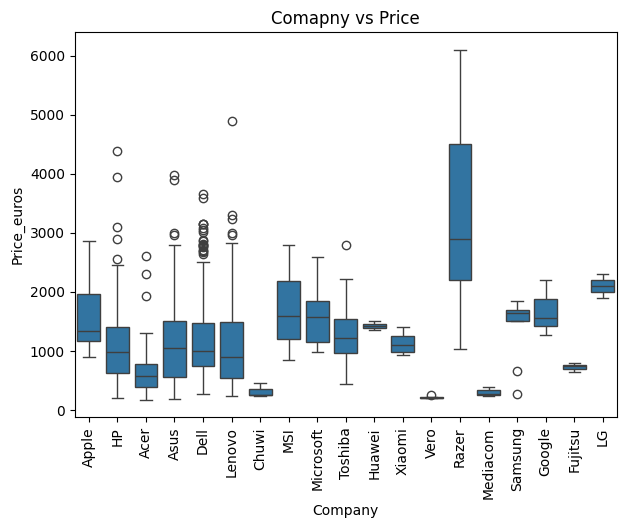

In [13]:
# Comapny vs Price Analysis:

plt.figure(figsize=(7,5))
sns.boxplot(data=data, x=data['Company'], y=data['Price_euros'])
plt.xticks(rotation=90)
plt.title("Comapny vs Price")
plt.show() 

The boxplot shows that different companies have different price distributions. "RAZER" has the highest median laptop price, indicating that it mainly sells premium laptops, while "VERO" has the lowest median price suggesting budget devices. "LENOVO" shows the largest price variation, ranging from around €300 to €5000, meaning it serves both budget and high-end markets. "DELL" shows many outliers, indicating the presence of some very expensive laptops.

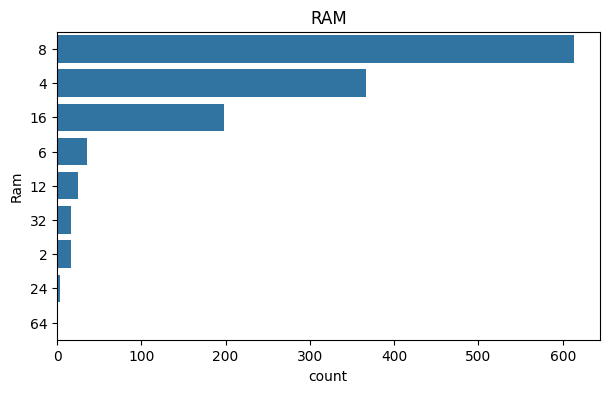

In [14]:
# RAM Analysis:

plt.figure(figsize=(7,4))
sns.countplot(data=data, y=data['Ram'], order=data['Ram'].value_counts().index)
plt.title("RAM")
plt.show()

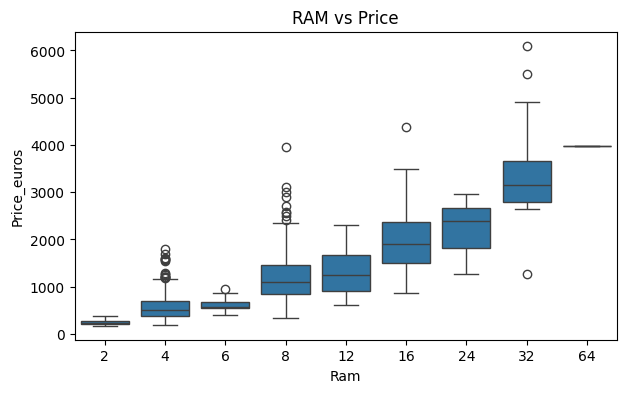

In [15]:
# RAM vs Price Anlaysis:

plt.figure(figsize=(7,4))
sns.boxplot(data=data, x=data['Ram'], y=data['Price_euros'])
plt.title("RAM vs Price")
plt.show()

RAM has a positive relationship with price, meaning laptops with higher RAM generally cost more.

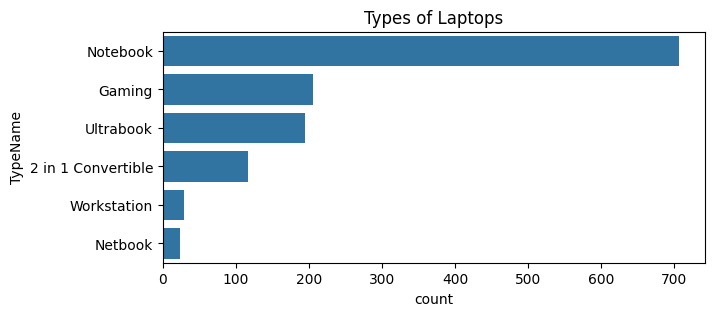

In [16]:
# Types of Laptop: 

plt.figure(figsize=(7,3))
sns.countplot(data=data, y=data['TypeName'], order=data['TypeName'].value_counts().index)
plt.title("Types of Laptops")
plt.show()

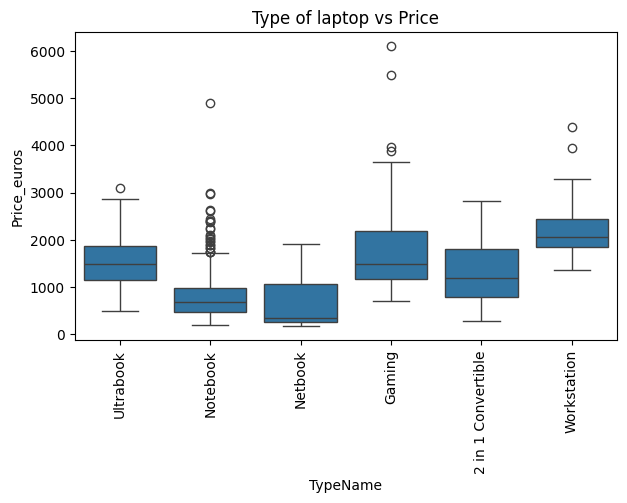

In [17]:
# Type of laptop vs Price Analysis:

plt.figure(figsize=(7,4))
sns.boxplot(data=data, x=data['TypeName'], y=data['Price_euros'])
plt.title("Type of laptop vs Price")
plt.xticks(rotation=90)
plt.show()

The most common laptop type in the dataset is "Notebook", indicating that general-purpose laptops are most widely purchased. Although notebooks are generally cheaper, some premium models appear as outliers with prices reaching up to €5000.

"Netbooks" are the cheapest category with a median price below €500.

"Gaming" and "Workstation" laptops are the most expensive categories due to their high-performance hardware.

Mean: 2.0405254901960785
Median: 2.04


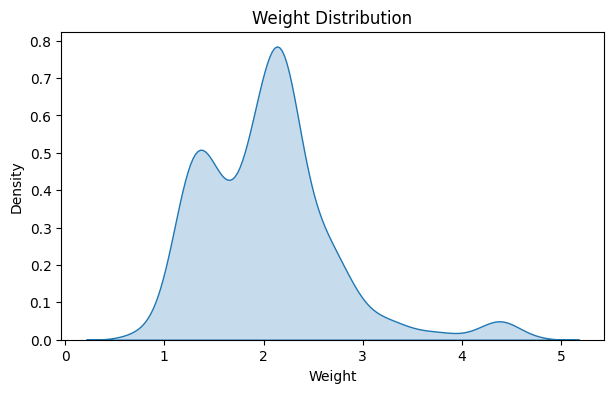

In [18]:
# Weight Distribution:

print(f"Mean: {data['Weight'].mean()}")
print(f"Median: {data['Weight'].median()}")

plt.figure(figsize=(7,4))
sns.kdeplot(data=data, x=data['Weight'], fill=True)
plt.title("Weight Distribution")
plt.show()

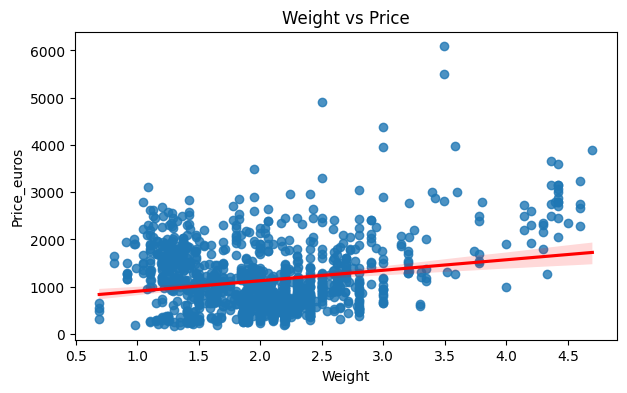

In [19]:
# Weight vs Price Analysis:

plt.figure(figsize=(7,4))
sns.regplot(data=data, x=data['Weight'], y=data['Price_euros'], line_kws={'color':'red'})
plt.title("Weight vs Price")
plt.show()

From the KDE plot, it can be observed that most people purchase laptops weighing around 2 kg, with another noticeable group of laptops around 1.5 kg, indicating that these weight ranges are the most common in the dataset, and that data is normallly distributed.

The regression-plot shows that there is no strong relationship between weight and price. Increasing the weight of a laptop does not necessarily lead to an increase in price.

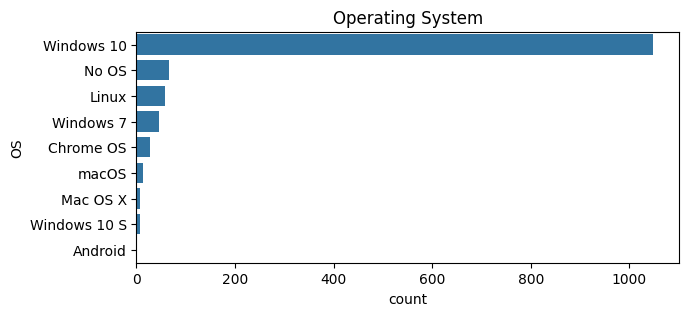

In [20]:
# Operating System Analysis:

plt.figure(figsize=(7,3))
sns.countplot(data=data, y=data['OS'], order=data['OS'].value_counts().index)
plt.title("Operating System")
plt.show()

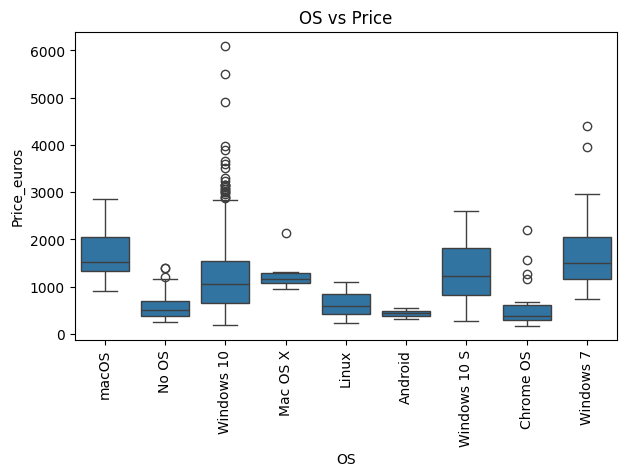

In [21]:
# OS vs Price Analysis:

plt.figure(figsize=(7,4))
sns.boxplot(data=data, x=data['OS'], y=data['Price_euros'])
plt.title("OS vs Price")
plt.xticks(rotation=90)
plt.show()

Windows laptops has most share in the market and we can also confirm it from the graph as they are cheap as well as pricy too, as many expensive laptops also use windows os.

macos laptops are generally expensive which is expected as Apple positions its products as premium devices.

Windows 7 also show relatively high prices, which may be due to certain high-end or business laptops in the dataset rather than the operating system itself.

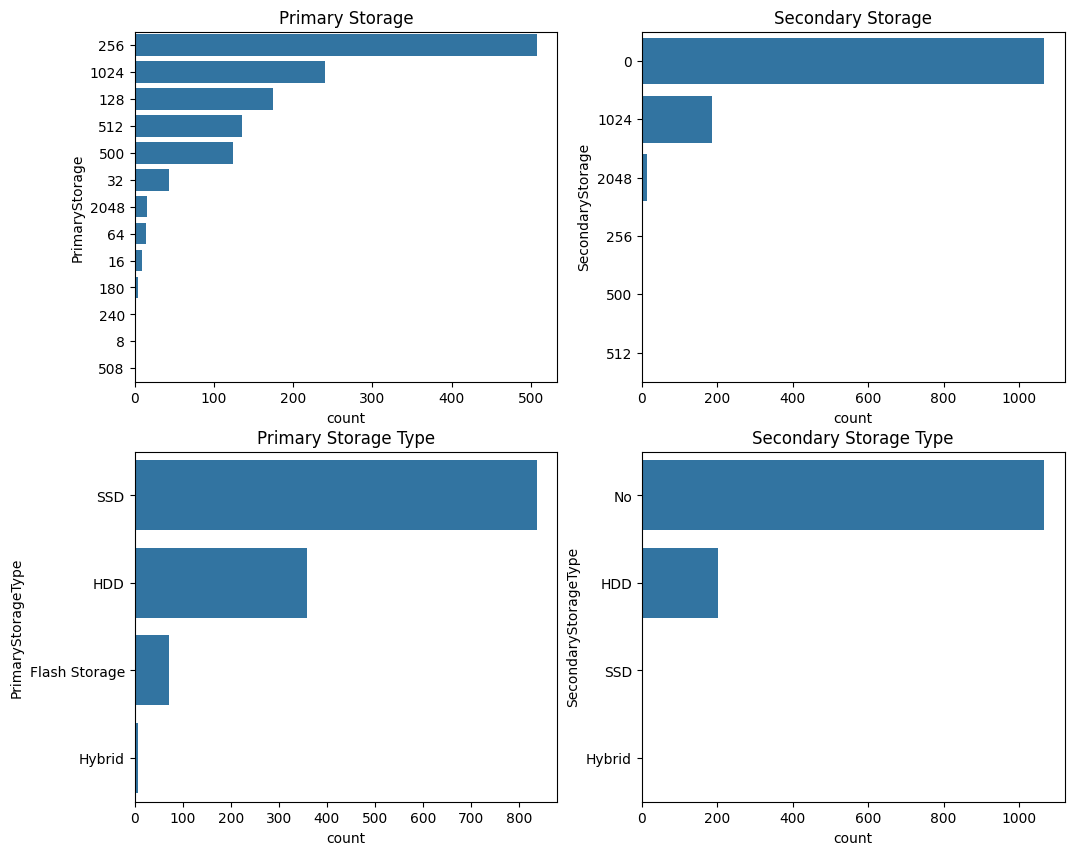

In [22]:
# Storage Analysis:

fig, ax  = plt.subplots(nrows=2, ncols=2, figsize=(12,10))

sns.countplot(data=data, y=data['PrimaryStorage'], order=data['PrimaryStorage'].value_counts().index, ax=ax[0][0])
ax[0][0].set_title("Primary Storage")

sns.countplot(data=data, y=data['SecondaryStorage'], order=data['SecondaryStorage'].value_counts().index, ax=ax[0][1])
ax[0][1].set_title("Secondary Storage")

sns.countplot(data=data, y=data['PrimaryStorageType'], order=data['PrimaryStorageType'].value_counts().index, ax=ax[1][0])
ax[1][0].set_title("Primary Storage Type")

sns.countplot(data=data, y=data['SecondaryStorageType'], order=data['SecondaryStorageType'].value_counts().index, ax=ax[1][1])
ax[1][1].set_title("Secondary Storage Type")

plt.show()

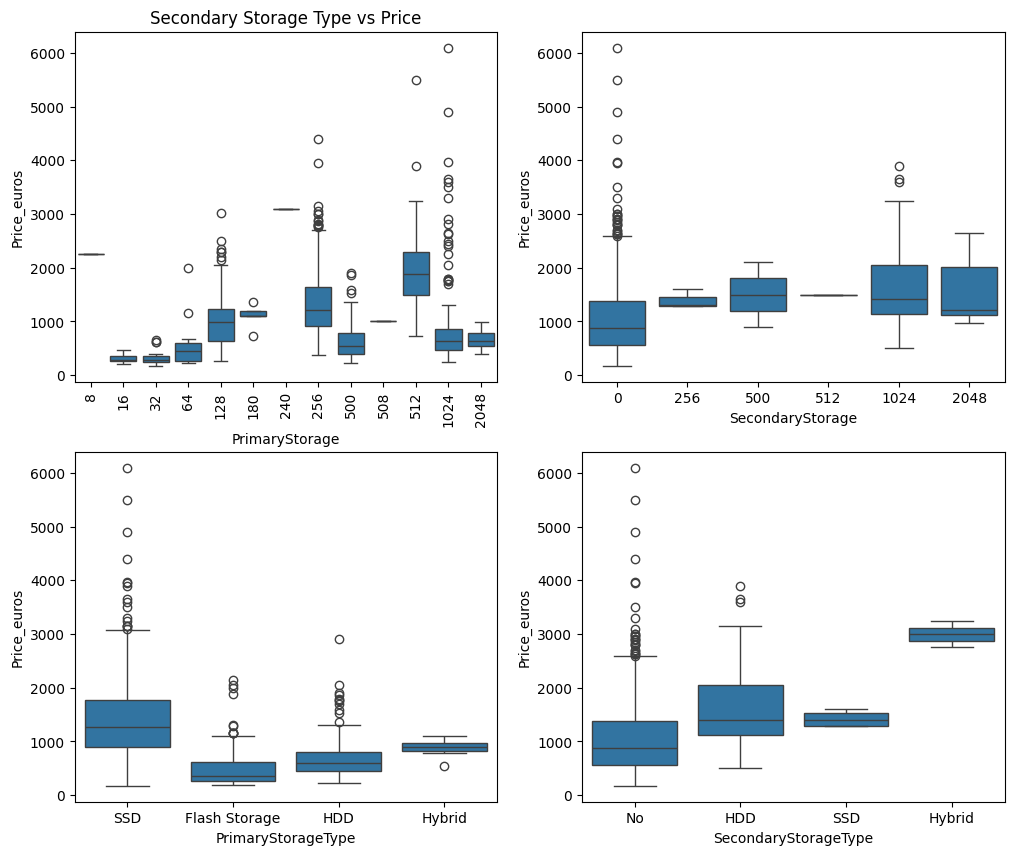

In [23]:
# Storage vs Price Analysis:

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,10))

sns.boxplot(data=data, x=data['PrimaryStorage'], y=data['Price_euros'], ax=ax[0][0])
ax[0][0].set_title("Primary Storage vs Price")
ax[0][0].tick_params(axis='x', rotation=90)

sns.boxplot(data=data, x=data['SecondaryStorage'], y=data['Price_euros'], ax=ax[0][1])
ax[0][0].set_title("Secondary Storage vs Price")

sns.boxplot(data=data, x=data['PrimaryStorageType'], y=data['Price_euros'], ax=ax[1][0])
ax[0][0].set_title("Primary Storage Type vs Price")

sns.boxplot(data=data, x=data['SecondaryStorageType'], y=data['Price_euros'], ax=ax[1][1])
ax[0][0].set_title("Secondary Storage Type vs Price")

plt.show()

Most laptops in the dataset use 256GB as primary storage, with a median price around €1000. Increasing storage size does not significantly increase price, suggesting that storage capacity alone is not a major determinant of laptop price.

Most laptops do not have secondary storage, indicating that modern laptops generally rely on a single storage device.

In terms of storage type, SSD is the most common primary storage type, and laptops with SSD tend to be more expensive than those with HDD due to better performance and faster speeds.

For secondary storage, the few laptops that include it mostly use HDD, while Hybrid storage devices

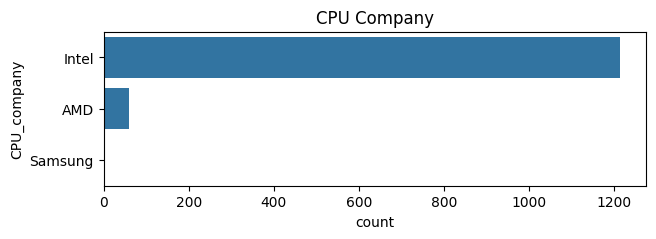

In [24]:
# CPU Analysis:

plt.figure(figsize=(7,2))
sns.countplot(data=data, y=data['CPU_company'], order=data['CPU_company'].value_counts().index)
plt.title("CPU Company")
plt.show()

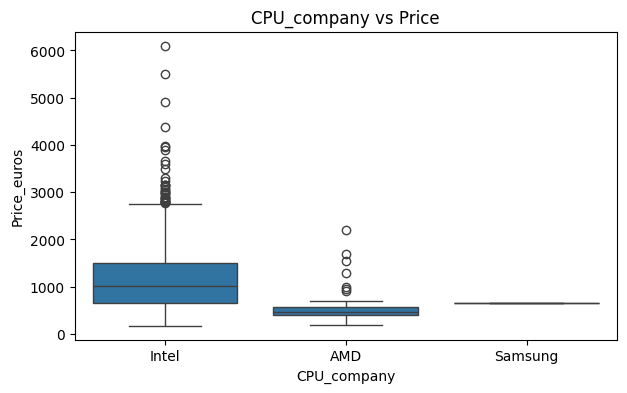

In [25]:
# CPU vs Price Analysis: 

plt.figure(figsize=(7,4))
sns.boxplot(data=data, x=data['CPU_company'], y=data['Price_euros'])
plt.title("CPU_company vs Price")
plt.show()

The CPU analysis shows that Intel processors dominate the dataset, appearing in most laptops. Intel-based laptops cover a wide price range from around €300 to €3000, with some high-end outliers reaching €6000. This wide range occurs because Intel processors are used across budget, mid-range, and premium laptops.

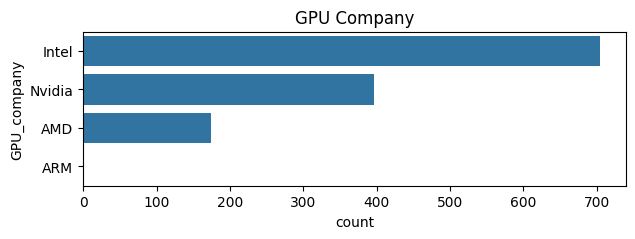

In [26]:
# GPU Analysis:

plt.figure(figsize=(7,2))
sns.countplot(data=data, y=data['GPU_company'], order=data['GPU_company'].value_counts().index)
plt.title("GPU Company")
plt.show()

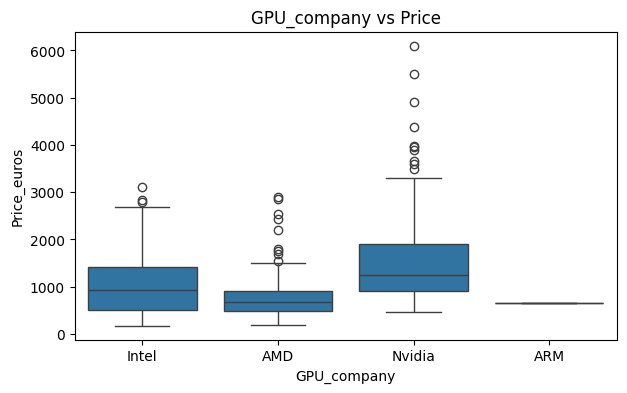

In [27]:
# GPU vs Price Analysis:

plt.figure(figsize=(7,4))
sns.boxplot(data=data, x=data['GPU_company'], y=data['Price_euros'])
plt.title("GPU_company vs Price")
plt.show()

GPU analysis shows that Intel GPUs appear most frequently, which indicates that many laptops use integrated graphics. Integrated GPUs are sufficient for general-purpose tasks such as browsing and office work. On the other hand, laptops with NVIDIA GPUs tend to have higher prices, as these GPUs are commonly used in gaming and high-performance laptops that require dedicated graphics processing.

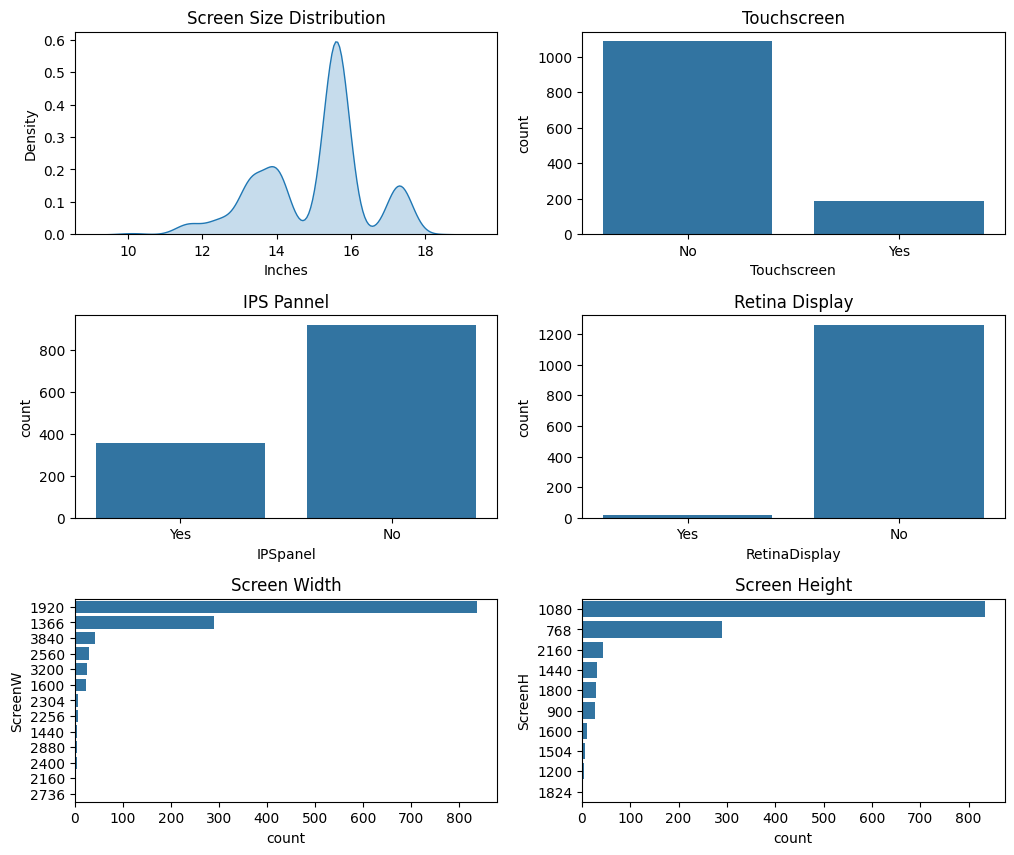

In [28]:
# Screen Analysis:

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12,10))
plt.subplots_adjust(hspace=0.4)

sns.kdeplot(data=data, x=data['Inches'], fill=True, ax=ax[0][0])
ax[0][0].set_title("Screen Size Distribution")

sns.countplot(data=data, x=data['Touchscreen'], ax=ax[0][1])
ax[0][1].set_title("Touchscreen")

sns.countplot(data=data, x=data['IPSpanel'], ax=ax[1][0]) 
ax[1][0].set_title("IPS Pannel")

sns.countplot(data=data, x=data['RetinaDisplay'], ax=ax[1][1]) 
ax[1][1].set_title("Retina Display")

sns.countplot(data=data, y=data['ScreenW'],order=data['ScreenW'].value_counts().index, ax=ax[2][0]) 
ax[2][0].set_title("Screen Width")

sns.countplot(data=data, y=data['ScreenH'],order=data['ScreenH'].value_counts().index, ax=ax[2][1]) 
ax[2][1].set_title("Screen Height")

plt.show()

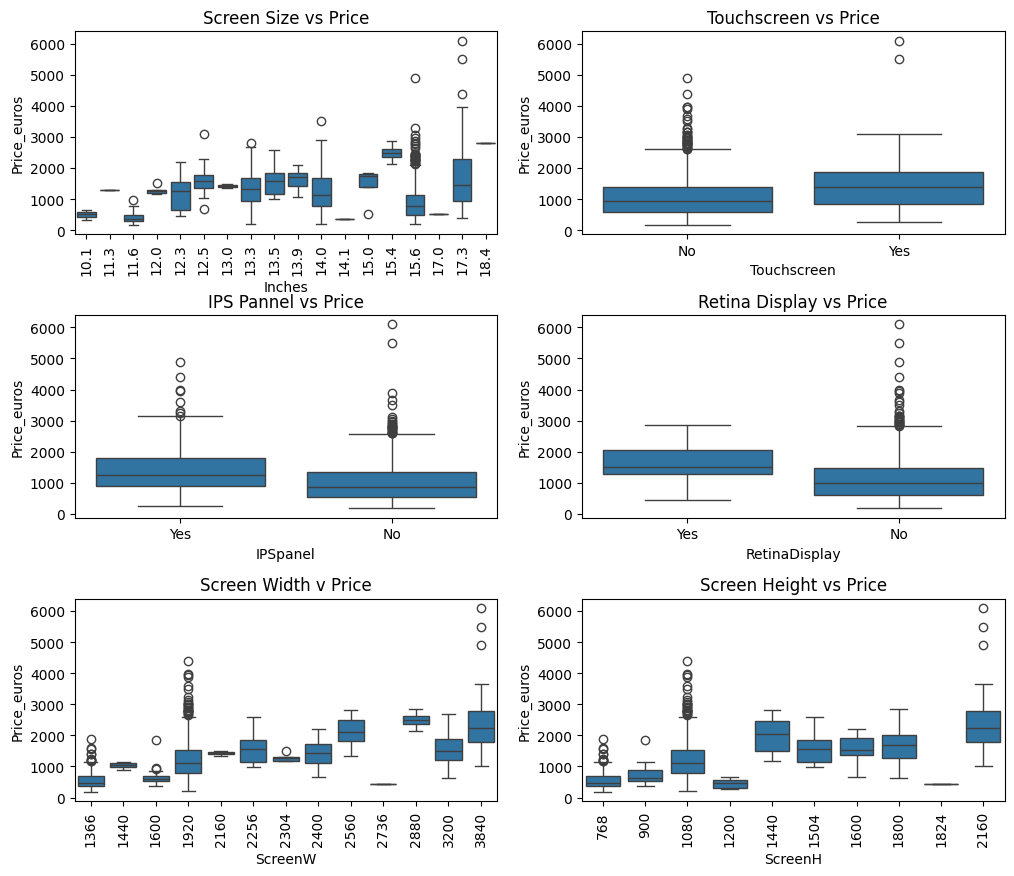

In [29]:
# Screen vs Price Analysis:

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12,10))
plt.subplots_adjust(hspace=0.4)

sns.boxplot(data=data, x=data['Inches'], y=data['Price_euros'], ax=ax[0][0])
ax[0][0].set_title("Screen Size vs Price")
ax[0][0].tick_params(axis='x', rotation=90)

sns.boxplot(data=data, x=data['Touchscreen'],y=data['Price_euros'], ax=ax[0][1])
ax[0][1].set_title("Touchscreen vs Price")

sns.boxplot(data=data, x=data['IPSpanel'],y=data['Price_euros'], ax=ax[1][0]) 
ax[1][0].set_title("IPS Pannel vs Price")

sns.boxplot(data=data, x=data['RetinaDisplay'],y=data['Price_euros'], ax=ax[1][1]) 
ax[1][1].set_title("Retina Display vs Price")

sns.boxplot(data=data, x=data['ScreenW'],y=data['Price_euros'], ax=ax[2][0]) 
ax[2][0].set_title("Screen Width v Price")
ax[2][0].tick_params(axis='x', rotation=90)

sns.boxplot(data=data, x=data['ScreenH'],y=data['Price_euros'], ax=ax[2][1]) 
ax[2][1].set_title("Screen Height vs Price")
ax[2][1].tick_params(axis='x', rotation=90)

plt.show()

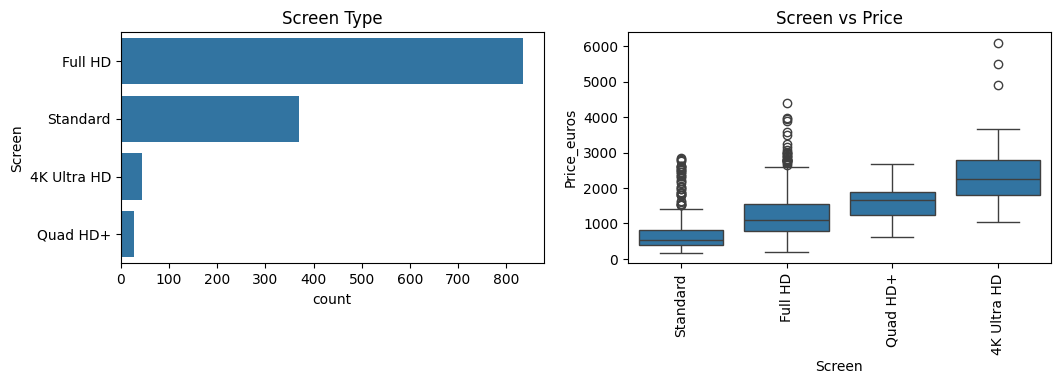

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,3))

sns.countplot(data=data, y=data['Screen'],order=data['Screen'].value_counts().index, ax=ax[0])
ax[0].set_title("Screen Type")

sns.boxplot(data=data, x=data['Screen'], y=data['Price_euros'], ax=ax[1])
ax[1].set_title("Screen vs Price")
ax[1].tick_params(axis='x', rotation=90)

plt.show()

Screen size analysis shows that 15.6-inch laptops are the most common, likely because they provide a balance between portability and usability. Larger laptops such as 17-inch models generally appear in higher price ranges, while some smaller laptops are also expensive due to premium ultrabook designs.

Most laptops in the dataset are non-touchscreen, indicating that touchscreen functionality is less common and typically appears in premium devices. Laptops with touchscreen displays generally have higher prices.

Panel analysis shows that IPS displays are less common but tend to appear in higher-priced laptops due to better display quality. Retina displays are mainly associated with Apple laptops, which are positioned as premium products.

Most laptops have 1920×1080 resolution (Full HD), which is the industry standard. Higher resolutions such as 4K displays are associated with higher-priced laptops, as they are typically found in premium devices.